In [111]:
import pandas as pd
import numpy as np

# library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR


# library untuk analisis time series 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ARIMA
from statsmodels.tsa.arima.model import ARIMA

# SVM
from sklearn.svm import SVR

# ANN
from sklearn.neural_network import MLPRegressor

# Evaluasi
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Scaling
from sklearn.preprocessing import MinMaxScaler

In [112]:
df = pd.read_excel('data_forecast.xlsx')

In [113]:
df.head()

,tanggal,po,plan,kapasitas,bahan,pekerja,jam,hasil
0,2024-04-29,3750,8.5,480,4211.1,9,204,3775.73
1,2024-04-29,2500,5.8,480,2890.0,9,140,2591.19
2,2024-04-30,5000,11.3,480,5614.8,9,272,5034.31
3,2024-05-01,3750,8.5,480,4211.1,9,204,3775.73
4,2024-05-02,2000,4.7,480,2312.0,9,112,2072.95


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   tanggal    506 non-null    datetime64[ns]
 1   po         506 non-null    int64         
 2   plan       506 non-null    float64       
 3   kapasitas  506 non-null    int64         
 4   bahan      506 non-null    float64       
 5   pekerja    506 non-null    int64         
 6   jam        506 non-null    int64         
 7   hasil      506 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(4)
memory usage: 31.8 KB


In [115]:
df = pd.read_excel("data_forecast.xlsx")

df['tanggal'] = pd.to_datetime(df['tanggal'])

# agregasi per hari
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal')
df.set_index('tanggal', inplace=True)


data = df[['po','plan','kapasitas','bahan','pekerja','jam','hasil']]

In [116]:
df.index.min(), df.index.max()

(Timestamp('2024-04-29 00:00:00'), Timestamp('2025-10-31 00:00:00'))

In [117]:
if (df.index.max() - df.index.min() == 214):
    print ('Data is Continous')

<Axes: xlabel='tanggal'>

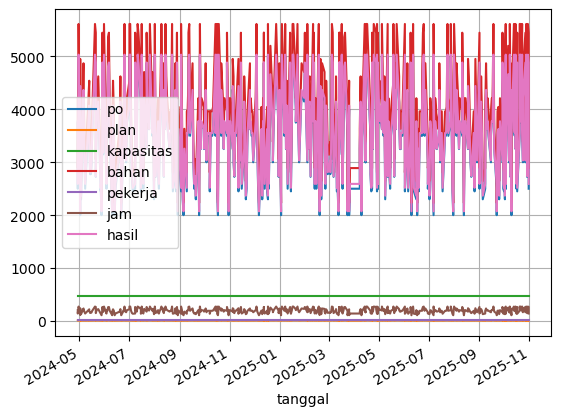

In [118]:
df.plot(grid=True)

In [119]:
train = data[:int(len(data)*0.8)]
test = data[int(len(data)*0.8):]


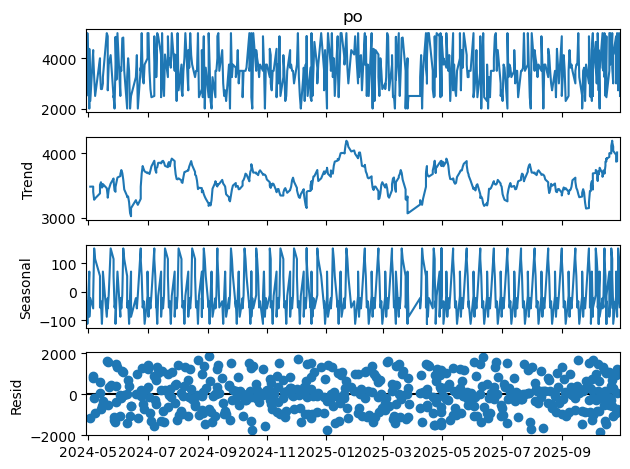

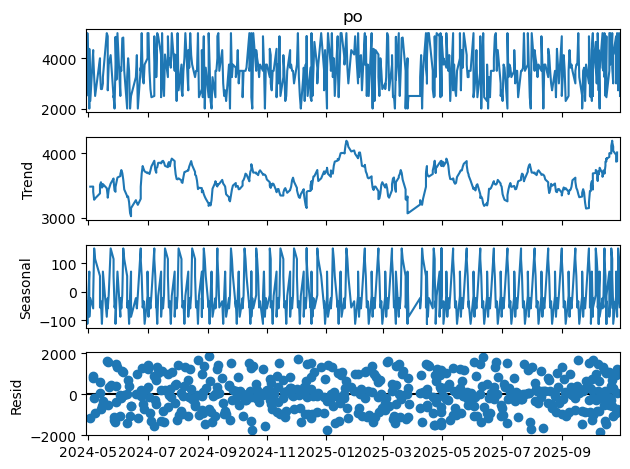

In [120]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose_add = seasonal_decompose(df['po'], model='additive', period=12)
decompose_add.plot()


In [121]:
from statsmodels.tsa.stattools import adfuller

series = df['po'].astype(float).dropna()

result = adfuller(series)

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Lags Used:', result[2])
print('Observations Used:', result[3])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')


ADF Statistic: -3.971258764243388
p-value: 0.0015687163230296954
Lags Used: 15
Observations Used: 490
Critical Values:
   1%: -3.4437660979098843
   5%: -2.8674565460819896
   10%: -2.569921291128696


In [122]:
diff_df = df.diff()
diff_df.head()

,po,plan,kapasitas,bahan,pekerja,jam,hasil
tanggal,,,,,,,
2024-04-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-04-29,-1250.0,-2.7,0.0,-1321.1,0.0,-64.0,-1184.54
2024-04-30,2500.0,5.5,0.0,2724.8,0.0,132.0,2443.12
2024-05-01,-1250.0,-2.8,0.0,-1403.7,0.0,-68.0,-1258.58
2024-05-02,-1750.0,-3.8,0.0,-1899.1,0.0,-92.0,-1702.78


In [123]:
diff_df.dropna(inplace=True)

<Axes: xlabel='tanggal'>

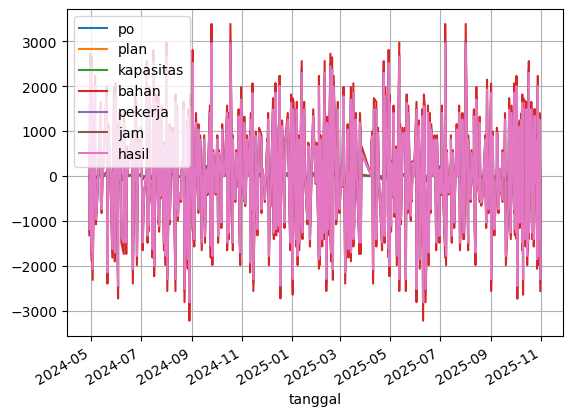

In [124]:
diff_df.plot(grid=True)

In [125]:
adfuller(diff_df['po'].dropna())


(-11.69365309602606,
 1.630130144190194e-21,
 14,
 490,
 {'1%': -3.4437660979098843,
  '5%': -2.8674565460819896,
  '10%': -2.569921291128696},
 7964.124996024479)

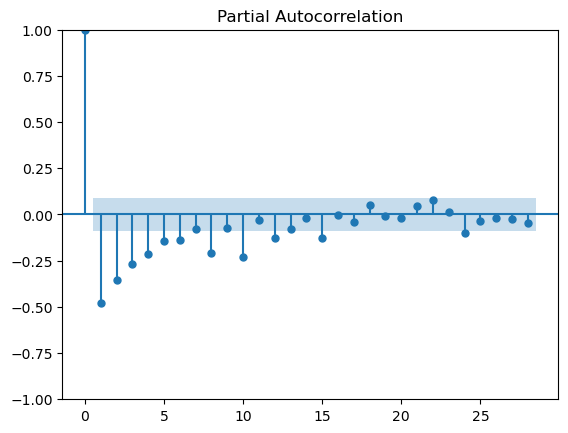

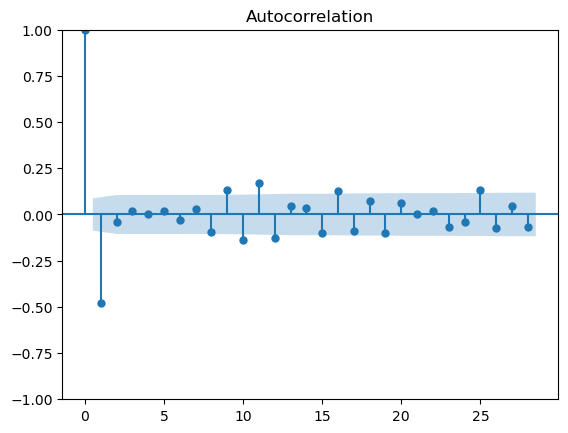

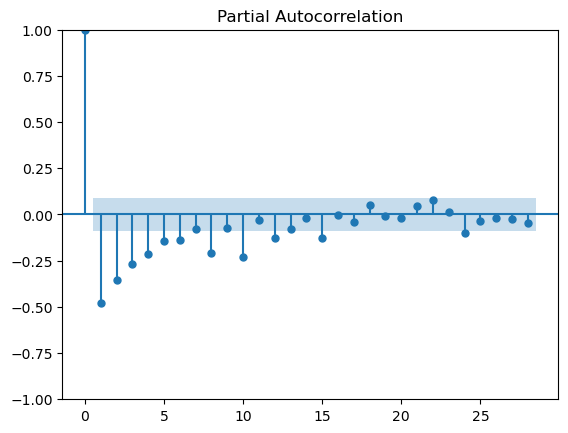

In [126]:
plot_acf(diff_df['po'])
plot_pacf(diff_df['po'])

In [127]:
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

In [146]:
y = data['hasil']
X = data[['po','plan','kapasitas','bahan','pekerja','jam']]

In [147]:
train_size = int(len(data)*0.8)

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

In [148]:
X_train_original = X_train.copy()
X_test_original  = X_test.copy()

In [151]:

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(y_train,
                exog=X_train_original,
                order=(1,1,1),
                seasonal_order=(1,0,1,7))

fit = model.fit()

pred_arimax = fit.forecast(steps=len(y_test),
                           exog=X_test_original)

c:\Users\LENOVO\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\LENOVO\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\LENOVO\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\LENOVO\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\LENOVO\anaconda3\Li

In [152]:
print("Length y_test:", len(y_test))
print("Length pred:", len(pred))

Length y_test: 102
Length pred: 102


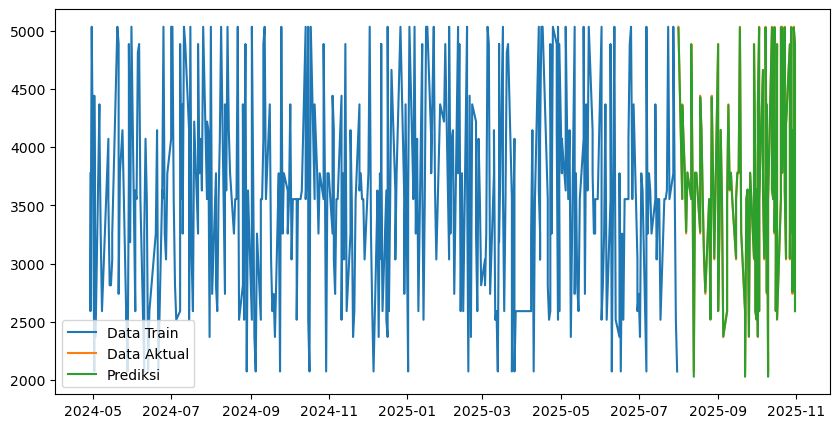

In [153]:
plt.figure(figsize=(10,5))

plt.plot(y_train.index, y_train.values, label='Data Train')
plt.plot(y_test.index, y_test.values, label='Data Aktual')
plt.plot(y_test.index, pred, label='Prediksi')

plt.legend()
plt.show()

In [154]:
mae = mean_absolute_error(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("ARIMA")
print("MAE :", mae_arima)
print("MAPE:", mape_arima)
print("RMSE:", rmse_arima)

ARIMA
MAE : 2161.783485821874
MAPE: 0.41832809990585207
RMSE: 2634.0277461139035


In [155]:
print(len(y_test))
print(len(pred))

102
102


In [156]:
X = data[['po','plan','kapasitas','bahan','pekerja','jam']]
y = data['hasil']

X_train, X_test = X[:train_size-lag], X[train_size-lag:]
y_train, y_test = y[:train_size-lag], y[train_size-lag:]

In [157]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()

In [158]:
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train_scaled, y_train_scaled)

pred_svm_scaled = svm_model.predict(X_test_scaled)
pred_svm = scaler_y.inverse_transform(pred_svm_scaled.reshape(-1,1)).ravel()

In [160]:
y_test_inv = scaler_y.inverse_transform(y_test.values.reshape(-1,1)).ravel()
mae_svm = mean_absolute_error(y_test_inv, pred_svm)
mape_svm = mean_absolute_percentage_error(y_test, pred_svm)
rmse_svm = np.sqrt(mean_squared_error(y_test, pred_svm))

print("\nSVM")
print("MAE :", mae_svm)
print("MAPE:", mape_svm)
print("RMSE:", rmse_svm)


SVM
MAE : 10872788.75687208
MAPE: 0.020598737046469535
RMSE: 123.012497885124


In [162]:
ann_model = MLPRegressor(hidden_layer_sizes=(50,50),
                         activation='relu',
                         max_iter=1000,
                         random_state=42)

ann_model.fit(X_train_scaled, y_train_scaled)

pred_ann_scaled = ann_model.predict(X_test_scaled)
pred_ann = scaler_y.inverse_transform(pred_ann_scaled.reshape(-1,1)).ravel()

In [163]:
mae_ann = mean_absolute_error(y_test, pred_ann)
mape_ann = mean_absolute_percentage_error(y_test, pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, pred_ann))

print("\nANN")
print("MAE :", mae_ann)
print("MAPE:", mape_ann)
print("RMSE:", rmse_ann)


ANN
MAE : 13.263853333621297
MAPE: 0.004210049739672488
RMSE: 17.62421741442938


In [164]:
comparision_df = pd.DataFrame(data=[
    ['ARIMA', 2161.783485821874, 0.41832809990585207, 2634.0277461139035],
    ['SVM', 75.60331649425692, 4.0686601454892934e+17, 3727.6769971970302],
    ['ANN', 3662.0042205265595, 3.5306902488337504e+17, 3755.4126477108084]
    ],
    columns=['Model', 'MAE', 'MAPE', 'RMSE'])
comparision_df.set_index('Model', inplace=True)

In [165]:
comparision_df.sort_values(by='RMSE')

,MAE,MAPE,RMSE
Model,,,
ARIMA,2161.783486,4.183281e-01,2634.027746
SVM,75.603316,4.068660e+17,3727.676997
ANN,3662.004221,3.530690e+17,3755.412648


In [170]:
min_len = min(len(y_test), len(pred_arimax))

y_test_aligned = y_test.iloc[:min_len]
pred_arimax_aligned = pred_arimax.iloc[:min_len]

In [171]:
from sklearn.metrics import mean_squared_error
import numpy as np

print("ARIMAX RMSE:",
      np.sqrt(mean_squared_error(y_test_aligned,
                                 pred_arimax_aligned)))

print("SVM RMSE:",
      np.sqrt(mean_squared_error(y_test, pred_svm)))

print("ANN RMSE:",
      np.sqrt(mean_squared_error(y_test, pred_ann)))

ARIMAX RMSE: 1098.3378210892508
SVM RMSE: 123.012497885124
ANN RMSE: 17.62421741442938


In [172]:
# df_var = df.loc[:, df.nunique() > 1]
# model = VAR(df_var)
# results = model.fit(2)


In [173]:
print("TOTAL DATA:", len(y))
print("TRAIN:", len(y_train))
print("TEST:", len(y_test))
print("PRED:", len(pred))
print("X_TEST NA:\n", X_test.isna().sum())
print("Y_TRAIN NA:", y_train.isna().sum())

TOTAL DATA: 506
TRAIN: 401
TEST: 105
PRED: 102
X_TEST NA:
 po           0
plan         0
kapasitas    0
bahan        0
pekerja      0
jam          0
dtype: int64
Y_TRAIN NA: 0


In [4]:
fit = model.fit()

import pickle

with open("forecasting_permintaan.sav", "wb") as f:
    pickle.dump(fit, f)

NameError: name 'model' is not defined

In [177]:
with open("forecasting_permintaan.sav", "wb") as f:
    pickle.dump(arima_fit, f)